# No preamble

In [3]:
from commstools import Signal, load_npz
from commstools.backend import dispatch
from commstools.equalization import lms, block_lms
from commstools.sync import (
    compensate_iq_imbalance_lowdin,
    correct_carrier_phase,
    correct_frequency_offset,
    correct_timing,
    estimate_timing,
    recover_carrier_phase_bps,
    recover_carrier_phase_pll,
)

TX_PATH = "/home/lokgar/repos/trmhi304-p2p/waveforms/signal_16qam"
RX_PATH = "/home/lokgar/repos/trmhi304-p2p/captures/capture_16qam_intradyne_long.npy"


2026-05-17 23:04:40 [INFO] [commstools/backend.py] CuPy is available and functional, defaulting Signals to GPU.


In [ ]:
def _to_cpu(x, xp):
    """Return ``x`` as a 1-D CPU numpy array regardless of backend."""
    return x.get() if hasattr(x, "get") else xp.asarray(x)


def find_bias_tone(seg_1d_cpu, fs, xp, target_hz=None, search_band_hz=None):
    """
    Sub-bin PSD-peak FOE.

    Locate the strongest spectral peak in `seg_1d_cpu` and refine its
    position via log-parabolic fit on the three bins around the argmax.
    Returns the refined peak frequency in Hz.

    Optional restriction: pass both ``target_hz`` and ``search_band_hz`` to
    limit the search to ``[target_hz ± search_band_hz]``.  Useful for
    tracking the bias tone after a coarse correction has placed it near a
    known target frequency, so the wider-band signal doesn't fool argmax.

    Parameters
    ----------
    seg_1d_cpu : 1-D complex numpy array (CPU)
    fs : sampling rate in Hz
    target_hz, search_band_hz : optional band restriction in Hz
    """
    x = xp.asarray(seg_1d_cpu)
    N = len(x)
    spec = xp.fft.fftshift(xp.fft.fft(x))
    Pxx = spec.real**2 + spec.imag**2
    f = xp.fft.fftshift(xp.fft.fftfreq(N, d=1.0 / fs))

    if target_hz is not None and search_band_hz is not None:
        band = xp.where(xp.abs(f - target_hz) < search_band_hz)[0]
        k = int(band[int(xp.argmax(Pxx[band]))])
    else:
        k = int(xp.argmax(Pxx))

    if 0 < k < N - 1:
        ym = xp.log(max(Pxx[k - 1], 1e-30))
        y0 = xp.log(max(Pxx[k], 1e-30))
        yp = xp.log(max(Pxx[k + 1], 1e-30))
        denom = ym - 2.0 * y0 + yp
        delta = 0.5 * (ym - yp) / denom if abs(denom) > 1e-30 else 0.0
    else:
        delta = 0.0
    return float(f[k] + delta * (fs / N))


def piecewise_carrier_phase(samples_1d, fs, block_size, overlap, estimator, xp, sp):
    """
    Build a per-sample carrier-phase trajectory from a per-block FOE.

    Mirrors the structure of `estimate_frequency_offset_blockwise` (overlap,
    cubic-spline interpolation between block centres, ``cumsum``-to-phase)
    but accepts an arbitrary per-block estimator callable.

    Parameters
    ----------
    samples_1d : (N,) complex array
    fs : sampling rate (Hz)
    block_size : analysis block length in samples
    overlap : fractional overlap in ``[0, 1)``
    estimator : callable ``(block_1d_cpu, fs) -> df_hz``

    Returns
    -------
    theta : (N,) float64 — per-sample phase trajectory in radians.
            Apply via ``correct_carrier_phase(samples, theta)``.
    """
    N = len(samples_1d)
    step = max(1, round(block_size * (1.0 - overlap)))
    starts = list(range(0, N - block_size + 1, step)) or [0]

    t_centers = xp.array([s + block_size / 2.0 for s in starts], dtype=xp.float64)
    dfs = xp.array(
        [estimator(samples_1d[s : s + block_size], fs) for s in starts],
        dtype=xp.float64,
    )
    print(
        f"    per-segment Δf:  mean = {dfs.mean():+.1f} Hz,  "
        f"std = {dfs.std():.1f} Hz,  "
        f"range = [{dfs.min():+.1f}, {dfs.max():+.1f}] Hz "
        f"({len(starts)} segments)"
    )

    n_grid = xp.arange(N, dtype=xp.float64)

    if len(starts) >= 2:
        spline = sp.interpolate.PchipInterpolator(t_centers, dfs, extrapolate=False)
        df_dense = spline(xp.clip(n_grid, t_centers[0], t_centers[-1]))
    else:
        df_dense = xp.full(N, dfs[0], dtype=xp.float64)

    return (2.0 * xp.pi / fs) * xp.cumsum(df_dense)


2026-05-17 23:23:38 [INFO] [commstools/sync.py] Applying Löwdin IQ imbalance compensation.


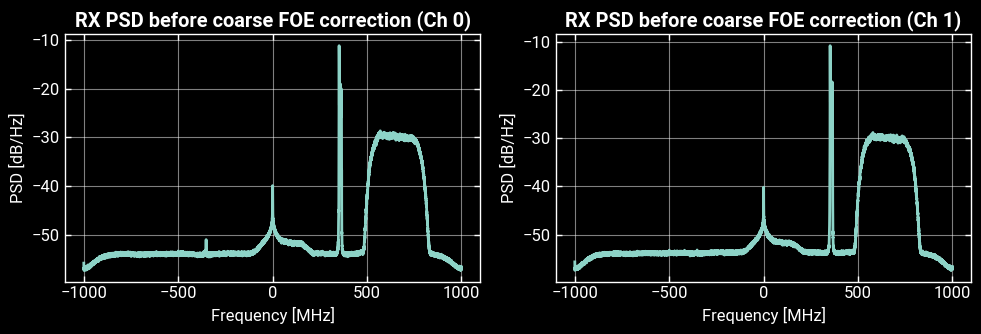

    bias-tone @ +352587523.131 MHz, applying shift = +652.591 MHz


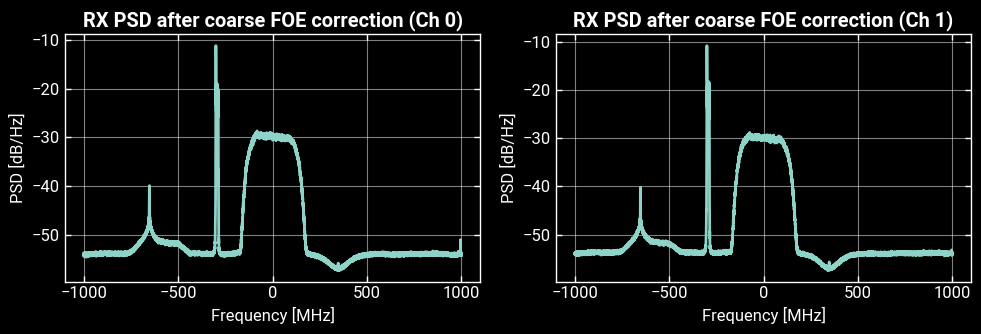

2026-05-17 23:23:39 [WARNING] [commstools/sync.py] Channel 0: Peak phase coherence is very low (0.31), but peak is visually prominent (PAPR=64.6 >= 3). This suggests strong Carrier Frequency Offset (CFO) or uncompensated dispersion destroying phase alignment over the sequence length.
2026-05-17 23:23:39 [WARNING] [commstools/sync.py] Channel 1: Peak phase coherence is very low (0.35), but peak is visually prominent (PAPR=66.4 >= 3). This suggests strong Carrier Frequency Offset (CFO) or uncompensated dispersion destroying phase alignment over the sequence length.
2026-05-17 23:23:39 [WARNING] [commstools/sync.py] Skew detected among valid channels! Valid Peaks: [59158, 59154]. Spread: 4 samples.


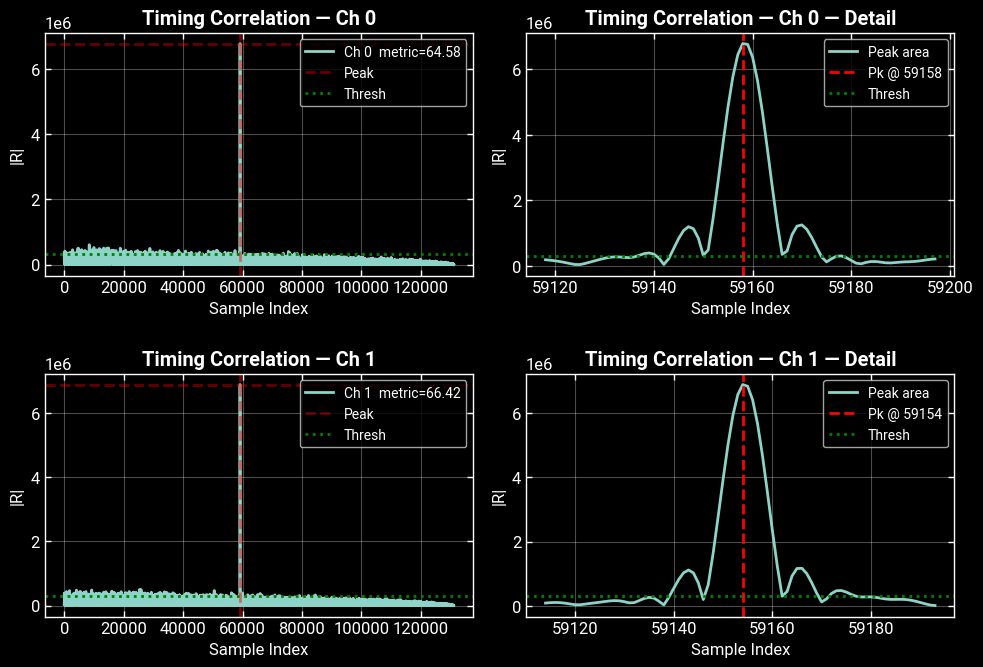

2026-05-17 23:23:43 [INFO] [commstools/sync.py] Timing estimated. Coarse: [59158, 59154], Fractional: [0.4331641242686477, 0.3562132750328686], Metrics: [64.58044650400544, 66.4245668298776]
2026-05-17 23:23:43 [WARNING] [commstools/sync.py] correct_timing(mode='slice'): output is shorter than input (trimmed by up to 59158 samples). Signal length metadata (e.g. duration) will no longer match the original.
2026-05-17 23:23:43 [INFO] [commstools/sync.py] Timing corrected: coarse=[59158, 59154], fractional=applied, mode='slice'.
    per-segment Δf:  mean = +3717839.4 Hz,  std = 4223513.7 Hz,  range = [-549350.1, +12548583.8] Hz (253 segments)


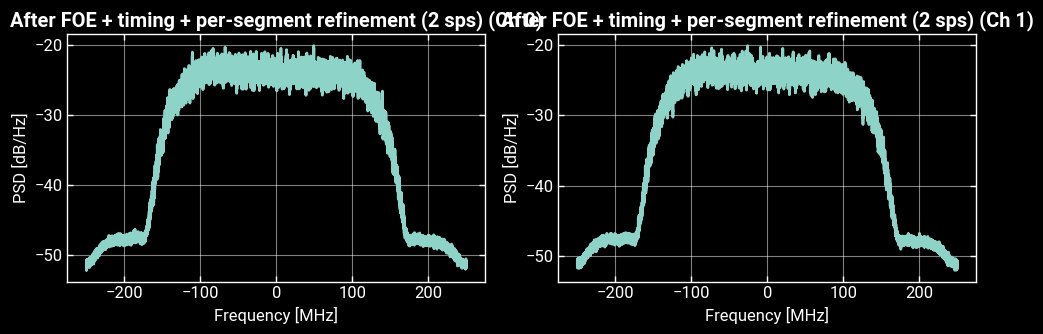

2026-05-17 23:23:44 [INFO] [commstools/core.py] Generating shaping filter taps (shape: rrc).


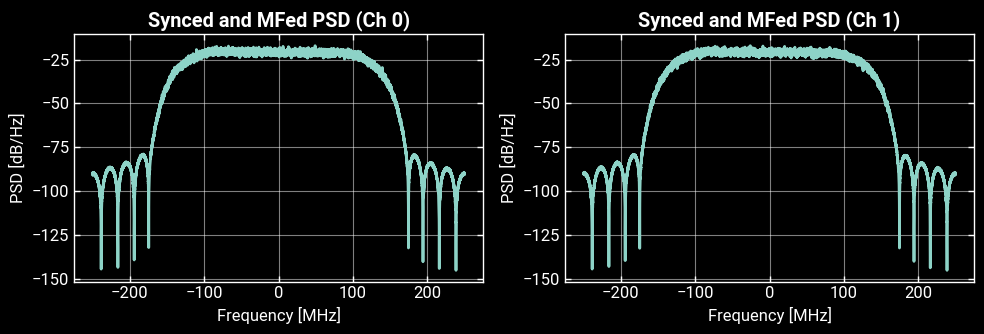

2026-05-17 23:23:48 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=35, mu=0.002, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-05-17 23:23:48 [WARNING] [commstools/equalization.py] LMS output y_hat is at 1 SPS (symbol rate). Update sampling_rate = symbol_rate after applying this equalizer.
2026-05-17 23:23:48 [INFO] [commstools/equalization.py] LMS: exit MSE (final 100 symbols): ch0=0.1, ch1=-0.1 dB
2026-05-17 23:23:48 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=35, mu=0.002, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-05-17 23:23:48 [WARNING] [commstools/equalization.py] LMS output y_hat is at 1 SPS (symbol rate). Update sampling_rate = symbol_rate after applying this equalizer.
2026-05-17 23:23:48 [INFO] [commstools/equalization.py] LMS: exit MSE (final 100 symbols): ch0=-2.9, ch1=-3.3 dB
2026-05-17 23:23:48 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=35, mu=0.002, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-05-17 23:23:

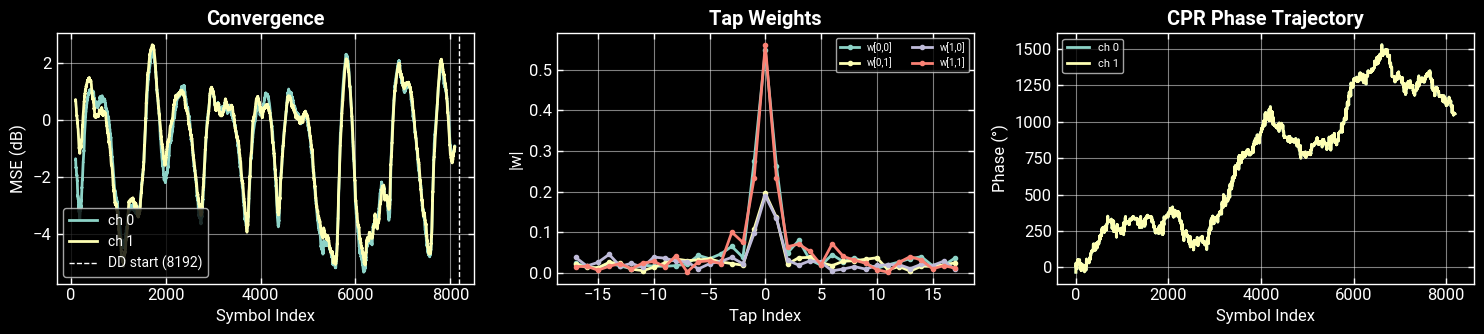

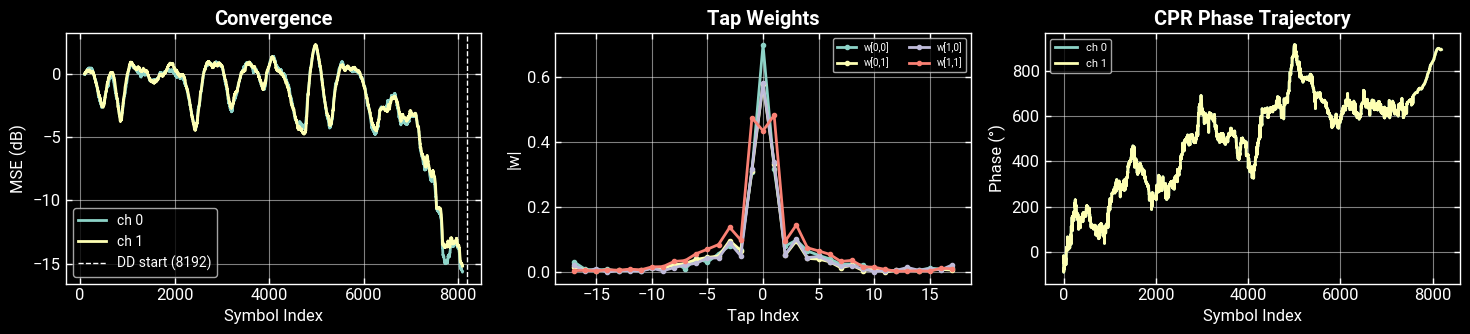

/home/lokgar/commstools/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


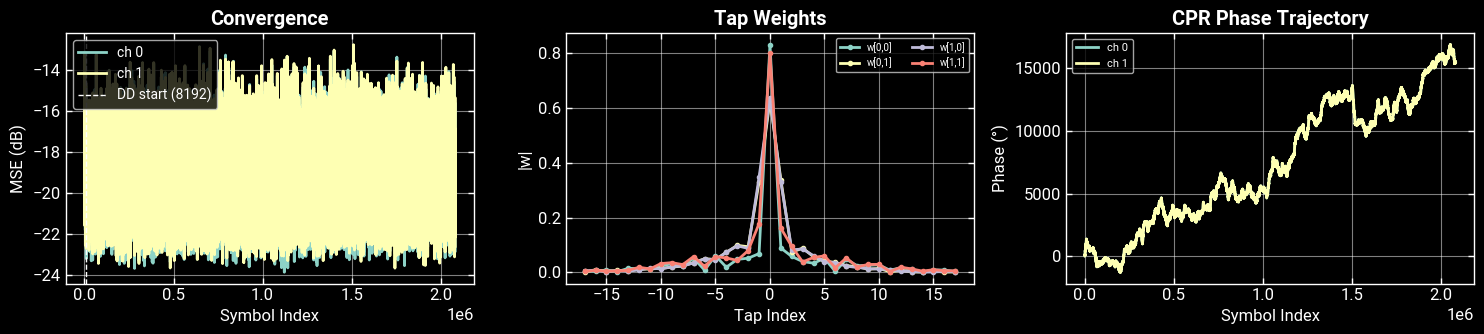

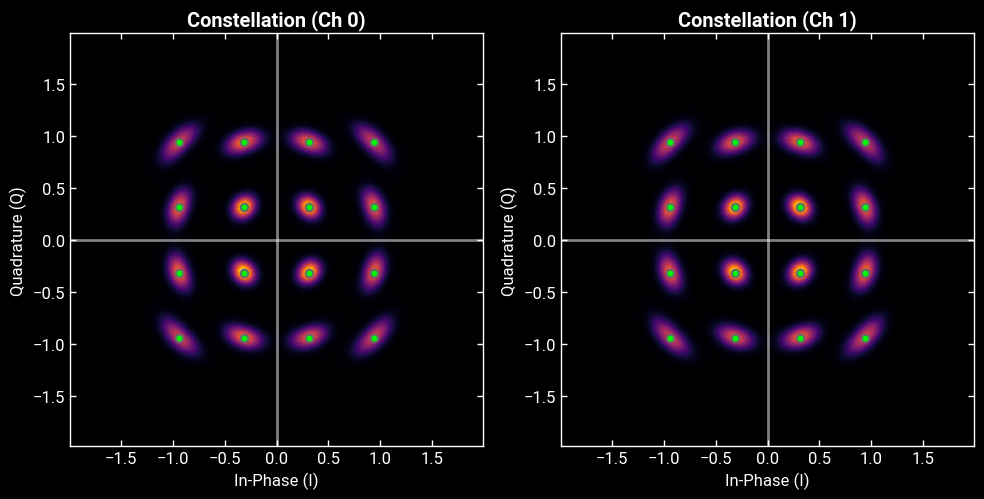

In [ ]:
# --------------------------------------------------------------------------
# 1. Reference TX waveform, brought to the ADC sample rate (8 sps)
# --------------------------------------------------------------------------
tx = load_npz(TX_PATH)
_, xp, sp = dispatch(tx.samples)

digoff = tx.digital_frequency_offset  # +300 MHz baked at TX
tx.shift_frequency(-digoff)  # strip it from the reference
tx.resample(up=1, down=2)  # 4 GSps → 2 GSps  (16 sps → 8 sps)
tile_len_adc = tx.samples.shape[-1]  # one DAC buffer at the ADC rate

# --------------------------------------------------------------------------
# 2. Capture: form 2-pol complex, fix IQ imbalance.
# --------------------------------------------------------------------------
rx_raw = xp.load(RX_PATH)
rx_samples = xp.array(
    [
        rx_raw[0] + 1j * rx_raw[1],
        rx_raw[2] + 1j * rx_raw[3],
    ]
)
rx_samples = compensate_iq_imbalance_lowdin(xp.conj(rx_samples))

rx = Signal(
    samples=rx_samples,
    sampling_rate=tx.sampling_rate,
    symbol_rate=tx.symbol_rate,
    mod_scheme=tx.frame.payload_mod_scheme,
    mod_order=tx.frame.payload_mod_order,
    frame=tx.frame,
    pulse_shape=tx.pulse_shape,
)

rx.plot_psd(title="RX PSD before coarse FOE correction", nperseg=2**15, show=True)

# --------------------------------------------------------------------------
# 3. Coarse FOE on the FIRST tile — drives the timing step.
#    Use the bias-leakage tone in the PSD with log-parabolic sub-bin
#    interpolation.  One sub-bin pass is enough precision for timing's
#    phase coherence; per-segment refinement comes later.
# --------------------------------------------------------------------------
f_b_coarse = find_bias_tone(rx.samples[0, :tile_len_adc], rx.sampling_rate, xp=xp)
coarse_shift = f_b_coarse + digoff  # puts bias at -digoff, signal at 0
print(
    f"    bias-tone @ {f_b_coarse:+.3f} MHz, "
    f"applying shift = {coarse_shift / 1e6:+.3f} MHz"
)
rx.samples = correct_frequency_offset(rx.samples, rx.sampling_rate, coarse_shift)

rx.plot_psd(title="RX PSD after coarse FOE correction", nperseg=2**15, show=True)

# --------------------------------------------------------------------------
# 4. Timing — first peak, slice mode.  Restrict the cross-correlation
#    search to the first 2 tiles so estimate_timing's argmax lands on the
#    FIRST tile peak (otherwise the strongest of many near-identical
#    tile-peaks wins, typically pointing deep into the capture).
# --------------------------------------------------------------------------
coarse, fract = estimate_timing(
    rx.samples,
    tx.samples,
    sps=rx.sps,
    search_range=(0, tile_len_adc),
    threshold=3,
    debug_plot=True,
)
rx.samples = correct_timing(rx.samples, coarse, fract, mode="slice")

# --------------------------------------------------------------------------
# 5. Truncate to an integer number of frames after the slice.
#    Doing this *after* the slice (not before) preserves up to one extra
#    frame relative to a pre-trim, since the raw trailing partial tile
#    can now contribute when it's bigger than `max(coarse)`.
# --------------------------------------------------------------------------
n_seg_adc = rx.samples.shape[-1] // tile_len_adc
rx.samples = rx.samples[:, : n_seg_adc * tile_len_adc]


# ─────────────────────────────────────────────────────────────────────
# 6. Per-segment refined FOE with a continuous-phase trajectory.
#    Search around the post-coarse bias-tone location (-digoff) in each
#    segment, compute the residual drift, cubic-spline-interpolate, and
#    integrate to a per-sample phase array applied via
#    correct_carrier_phase.  No phase discontinuities at boundaries.
# ─────────────────────────────────────────────────────────────────────
def per_segment_estimator(blk, fs):
    # After the coarse correction, the bias tone sits near -digoff.
    # Any deviation = the residual frequency drift to be removed.
    f_b_k = find_bias_tone(
        blk,
        fs,
        xp=xp,
        target_hz=-digoff,
        search_band_hz=20e6,  # ±20 MHz around -digoff is well clear of the signal
    )
    return f_b_k + digoff  # δf_k = current bias offset relative to target


theta = piecewise_carrier_phase(
    rx.samples[0, :],  # just one pol for FOE estimation
    rx.sampling_rate,
    block_size=tile_len_adc,
    overlap=0.5,
    estimator=per_segment_estimator,
    xp=xp,
    sp=sp,
)
rx.samples = correct_carrier_phase(rx.samples, theta)

# ─────────────────────────────────────────────────────────────────────
# 7. Resample reference and capture to 2 sps; the polyphase anti-alias
#    filter kills the now-stationary bias tone at -digoff = -300 MHz
#    (outside ±250 MHz Nyquist at 500 MSps).
# ─────────────────────────────────────────────────────────────────────
rx.resample(sps_out=2)
tx.resample(sps_out=2)
n_seg = rx.samples.shape[-1] // tx.samples.shape[-1]

rx.plot_psd(
    show=True,
    title="After FOE + timing + per-segment refinement (2 sps)",
    nperseg=2**15,
)

# ─────────────────────────────────────────────────────────────────────
# 8. Matched filter + tile source bits/symbols to the aligned frame count.
# ─────────────────────────────────────────────────────────────────────
rx.source_bits = xp.tile(tx.frame.payload_bits, (1, n_seg))
rx.source_symbols = xp.tile(tx.frame.payload_symbols, (1, n_seg))
rx.matched_filter()
rx.plot_psd(show=True, title="Synced and MFed PSD", nperseg=2**15)

# # ─────────────────────────────────────────────────────────────────────
# # 9. Iterative warm-started butterfly block-LMS with BPS CPR.
# #    Known limitation: CPR state resets to 0 on every block_lms entry.
# # ─────────────────────────────────────────────────────────────────────
# NUM_EQ = 5
# NUM_TRAIN = 2**14
# NUM_TAPS = 35
# BLOCK_SIZE = 256
# STEP_SIZE = 2e-4

# eq_kwargs = dict(
#     modulation=rx.mod_scheme,
#     order=rx.mod_order,
#     num_taps=NUM_TAPS,
#     step_size=STEP_SIZE,
#     sps=rx.sps,
#     block_size=BLOCK_SIZE,
#     cpr_type="bps",
#     cpr_bps_joint_channels=True,
#     cpr_bps_test_phases=1024,
#     cpr_bps_block_size=32,
#     cpr_cycle_slip_correction=True,
#     cpr_cycle_slip_history=64,
#     cpr_cycle_slip_threshold=xp.pi / 4,
#     plot_smoothing=200,
# )

# res = None
# for i in range(NUM_EQ):
#     res = block_lms(
#         samples=rx.samples[:, : NUM_TRAIN * 2],
#         training_symbols=rx.source_symbols[:, :NUM_TRAIN],
#         w_init=res.weights if res is not None else None,
#         debug_plot=(i == 0 or i == NUM_EQ - 1),
#         **eq_kwargs,
#     )

# # Final pass over the full sequence — pass training too (Issue A workaround).
# res = block_lms(
#     samples=rx.samples,
#     training_symbols=rx.source_symbols[:, :NUM_TRAIN],
#     w_init=res.weights,
#     debug_plot=True,
#     **eq_kwargs,
# )

# eq = rx.copy()
# eq.samples = res.y_hat
# eq.sampling_rate = rx.symbol_rate
# eq.plot_constellation(show=True, overlay_ideal=True)

# ─────────────────────────────────────────────────────────────────────
# 9. Iterative warm-started butterfly LMS with BPS CPR.
#    Known limitation: CPR state resets to 0 on every block_lms entry.
# ─────────────────────────────────────────────────────────────────────
NUM_EQ = 5
NUM_TRAIN = 2**13
NUM_TAPS = 35
STEP_SIZE = 2e-3

eq_kwargs = dict(
    modulation=rx.mod_scheme,
    order=rx.mod_order,
    num_taps=NUM_TAPS,
    step_size=STEP_SIZE,
    sps=rx.sps,
    cpr_type="bps",
    cpr_joint_channels=True,
    cpr_bps_test_phases=1024,
    cpr_bps_block_size=32,
    cpr_cycle_slip_correction=True,
    cpr_cycle_slip_history=64,
    cpr_cycle_slip_threshold=xp.pi / 4,
    plot_smoothing=200,
)

res = None
for i in range(NUM_EQ):
    res = lms(
        samples=rx.samples[:, : NUM_TRAIN * 2],
        training_symbols=rx.source_symbols[:, :NUM_TRAIN],
        w_init=res.weights if res is not None else None,
        debug_plot=(i == 0 or i == NUM_EQ - 1),
        **eq_kwargs,
    )

# Final pass over the full sequence — pass training too (Issue A workaround).
res = lms(
    samples=rx.samples,
    training_symbols=rx.source_symbols[:, :NUM_TRAIN],
    w_init=res.weights,
    debug_plot=True,
    **eq_kwargs,
)

eq = rx.copy()
eq.samples = res.y_hat
eq.sampling_rate = rx.symbol_rate
eq.plot_constellation(show=True, overlay_ideal=True)


2026-05-17 23:25:37 [INFO] [commstools/sync.py] CPR (BPS, B=1024, joint): phase mean=0.12°, std=4.80° [65024 blocks x 32 symbols, C=2, cycle_slip_correction=True]


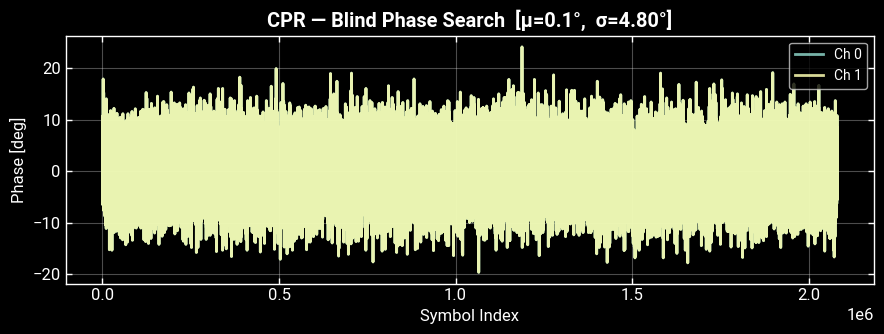

2026-05-17 23:25:38 [INFO] [commstools/core.py] Signal already at 1 sps, no downsampling needed.
2026-05-17 23:25:38 [INFO] [commstools/metrics.py] SER: 6.97e-05 (145/2080768 errors)
2026-05-17 23:25:38 [INFO] [commstools/metrics.py] SER: 1.00e+00 (2080768/2080768 errors)
2026-05-17 23:25:38 [INFO] [commstools/metrics.py] SER: 1.00e+00 (2080768/2080768 errors)
2026-05-17 23:25:38 [INFO] [commstools/metrics.py] SER: 1.00e+00 (2080768/2080768 errors)
2026-05-17 23:25:38 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=0, best_k=0, rotation=0.0°, SER=0.0001
2026-05-17 23:25:38 [INFO] [commstools/metrics.py] SER: 6.82e-05 (142/2080768 errors)
2026-05-17 23:25:38 [INFO] [commstools/metrics.py] SER: 1.00e+00 (2080768/2080768 errors)
2026-05-17 23:25:38 [INFO] [commstools/metrics.py] SER: 1.00e+00 (2080768/2080768 errors)
2026-05-17 23:25:38 [INFO] [commstools/metrics.py] SER: 1.00e+00 (2080768/2080768 errors)
2026-05-17 23:25:38 [INFO] [commstools/sync.py] Phase ambiguity resolutio

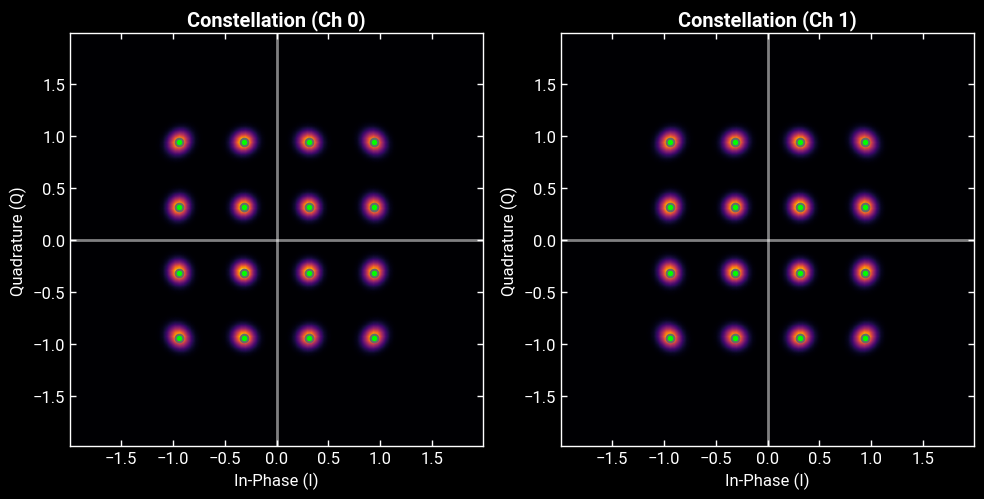

2026-05-17 23:25:39 [INFO] [commstools/core.py] Discarding 8192 training symbols for EVM calculation.
2026-05-17 23:25:39 [INFO] [commstools/metrics.py] EVM [blind] Ch0: 7.29% (-22.75 dB)
2026-05-17 23:25:39 [INFO] [commstools/metrics.py] EVM [blind] Ch1: 7.38% (-22.64 dB)
2026-05-17 23:25:39 [INFO] [commstools/core.py] Discarding 8192 training symbols for SER calculation.
2026-05-17 23:25:39 [INFO] [commstools/metrics.py] SER Ch0: 6.95e-05 (144/2072576 errors)
2026-05-17 23:25:39 [INFO] [commstools/metrics.py] SER Ch1: 6.75e-05 (140/2072576 errors)
2026-05-17 23:25:39 [INFO] [commstools/core.py] Discarding 8192 training symbols for SNR calculation.
2026-05-17 23:25:39 [INFO] [commstools/metrics.py] SNR Ch0: 22.74 dB
2026-05-17 23:25:39 [INFO] [commstools/metrics.py] SNR Ch1: 22.64 dB


array([22.737366, 22.63607 ], dtype=float32)

In [30]:
# ─────────────────────────────────────────────────────────────────────
# 10. Standalone BPS-CPR on the equalized output, then phase ambiguity
#     resolution and hard demap.
# ─────────────────────────────────────────────────────────────────────
phases_bps = recover_carrier_phase_bps(
    eq.samples,
    modulation=eq.mod_scheme,
    order=eq.mod_order,
    debug_plot=True,
    block_size=32,
    num_test_phases=1024,
    cycle_slip_correction=True,
    cycle_slip_history=64,
    cycle_slip_threshold=xp.pi / 4,
    joint_channels=True,
)

eqfoecpr = eq.copy()
eqfoecpr.samples = correct_carrier_phase(eqfoecpr.samples, phases_bps)
eqfoecpr.resolve_symbols()
eqfoecpr.resolve_phase_ambiguity()
eqfoecpr.demap_symbols_hard()
eqfoecpr.plot_constellation(show=True, overlay_ideal=True)

# ─────────────────────────────────────────────────────────────────────
# 11. Metrics.  EVM "blind" measures blob size against the nearest
#     constellation point.  SER/SNR discard `2 × NUM_TRAIN` symbols to
#     skip past the post-training CPR convergence region (Issue A).
# ─────────────────────────────────────────────────────────────────────
eqfoecpr.evm(num_train_symbols=NUM_TRAIN, mode="blind")
eqfoecpr.ser(num_train_symbols=NUM_TRAIN)
eqfoecpr.snr(num_train_symbols=NUM_TRAIN)


2026-05-16 18:59:17 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=75, mu=0.008, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-05-16 18:59:17 [WARNING] [commstools/equalization.py] LMS output y_hat is at 1 SPS (symbol rate). Update sampling_rate = symbol_rate after applying this equalizer.
2026-05-16 18:59:17 [INFO] [commstools/equalization.py] LMS: exit MSE (final 100 symbols): ch0=-21.3, ch1=-21.3 dB
2026-05-16 18:59:17 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=75, mu=0.008, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-05-16 18:59:17 [WARNING] [commstools/equalization.py] LMS output y_hat is at 1 SPS (symbol rate). Update sampling_rate = symbol_rate after applying this equalizer.
2026-05-16 18:59:17 [INFO] [commstools/equalization.py] LMS: exit MSE (final 100 symbols): ch0=-21.9, ch1=-21.6 dB
2026-05-16 18:59:17 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=75, mu=0.008, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-05-16 1

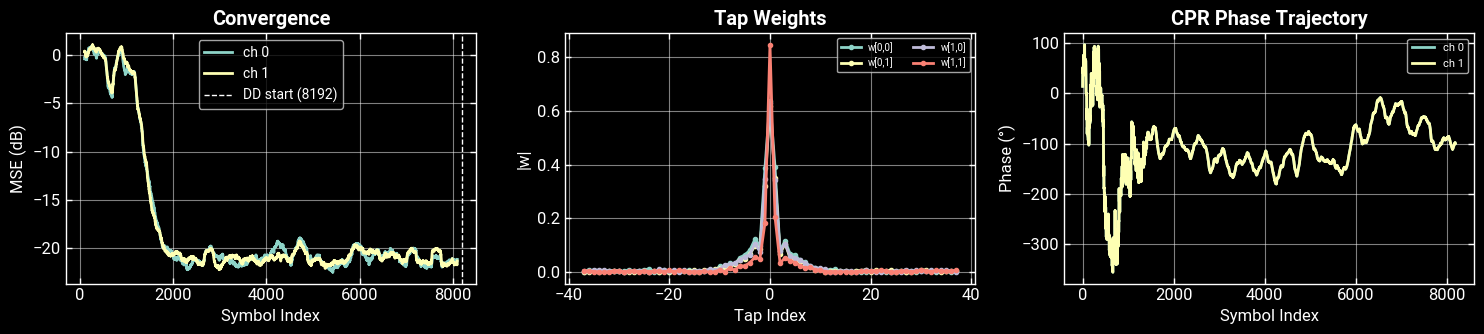

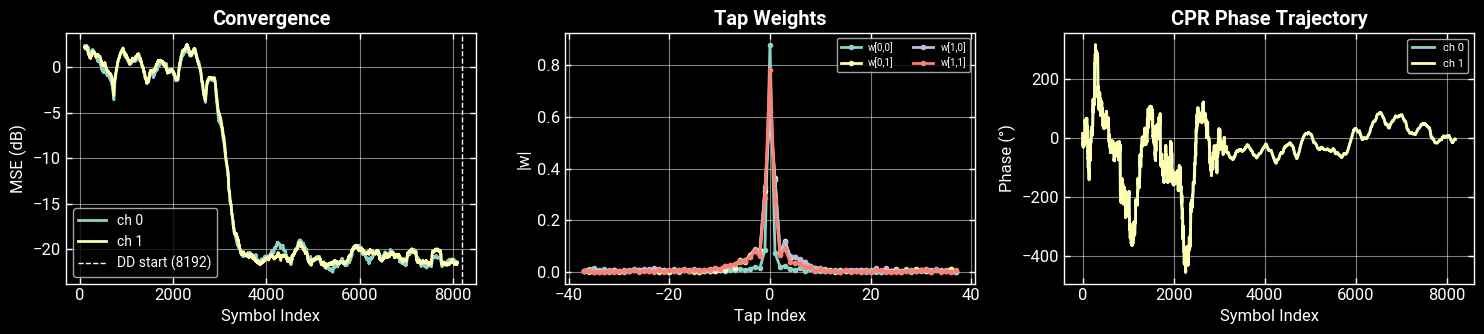

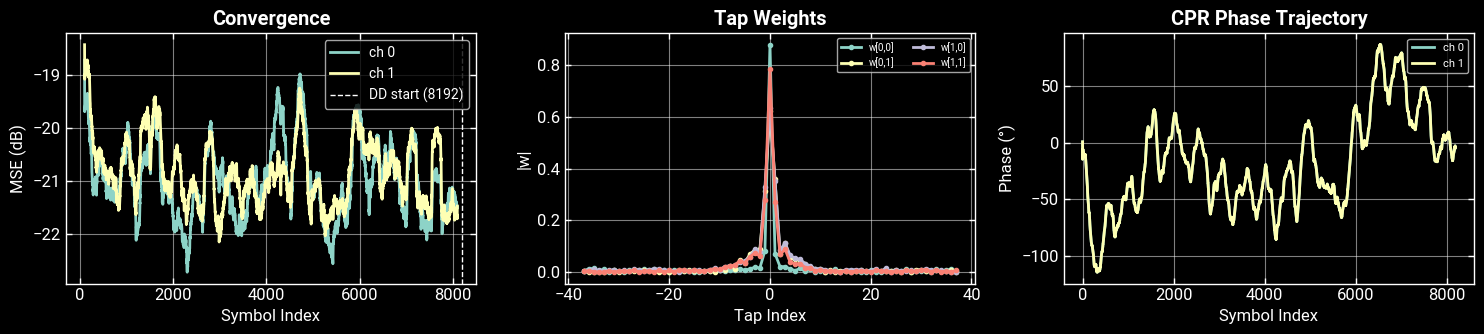

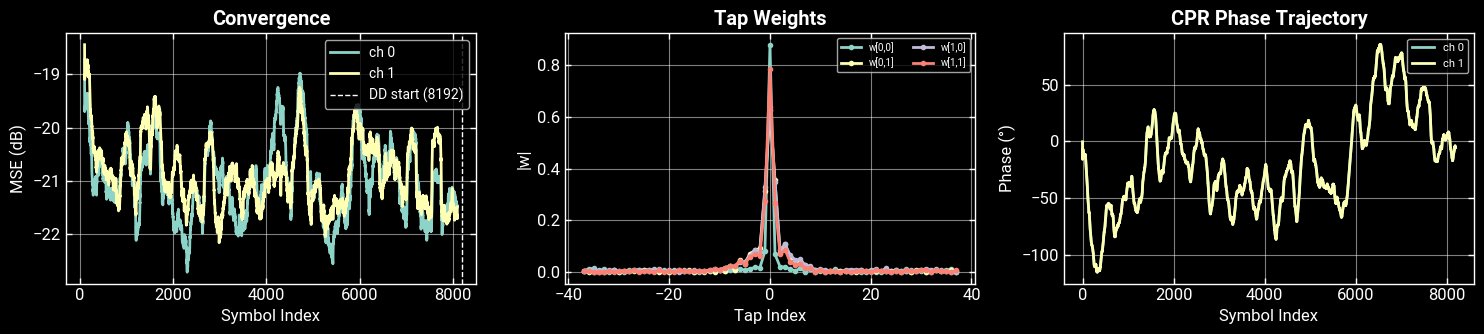

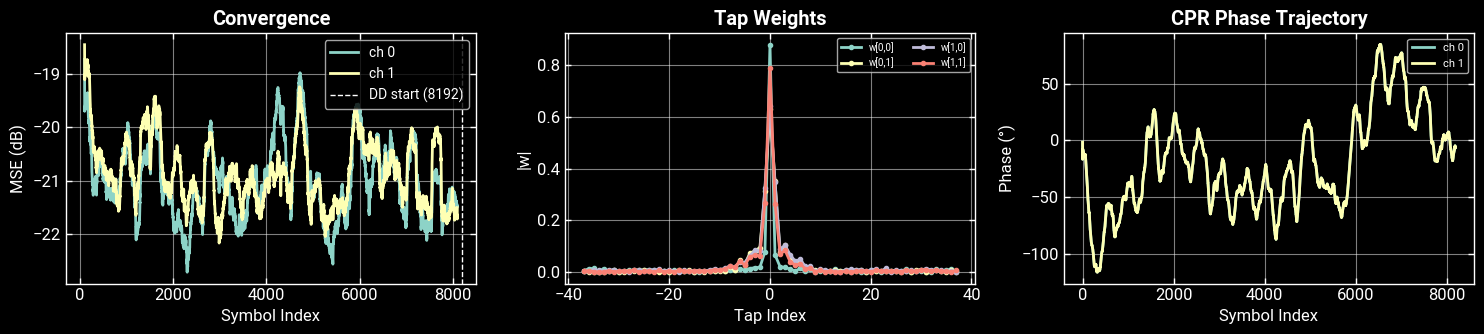

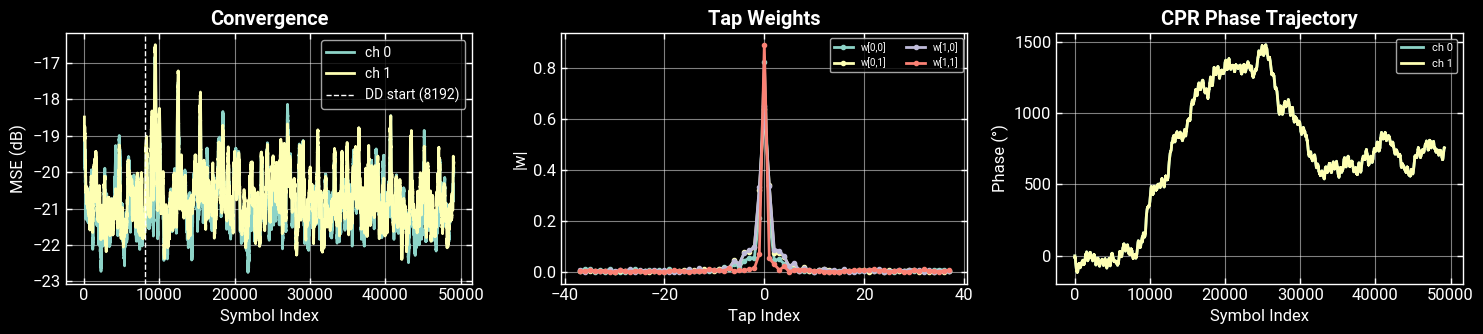

In [50]:
import jax


preeqsig = sig.copy()

numeq = 5
num_train_symbols = 2**13
num_taps = 75

step_size = 8e-3
cpr_type = "bps"
cpr_cycle_slip_correction = False
cpr_cycle_slip_history = 64
cpr_cycle_slip_threshold = xp.pi / 4
cpr_bps_test_phases = 1024
cpr_bps_block_size = 16
cpr_joint_channels = True

cpr_pll_bandwidth = 0.05

backend = "numba"

jax.config.update("jax_enable_x64", True)

for i in range(numeq):
    if i == 0:
        res = lms(
            samples=preeqsig.samples[:, : num_train_symbols * 2],
            training_symbols=preeqsig.source_symbols[:, :num_train_symbols],
            modulation=preeqsig.mod_scheme,
            order=preeqsig.mod_order,
            num_taps=num_taps,
            step_size=step_size,
            sps=preeqsig.sps,
            plot_smoothing=200,
            debug_plot=True,
            cpr_type=cpr_type,
            cpr_pll_bandwidth=cpr_pll_bandwidth,
            cpr_joint_channels=cpr_joint_channels,
            cpr_bps_test_phases=cpr_bps_test_phases,
            cpr_bps_block_size=cpr_bps_block_size,
            cpr_cycle_slip_correction=cpr_cycle_slip_correction,
            cpr_cycle_slip_history=cpr_cycle_slip_history,
            cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
            backend=backend,
        )
    elif i == numeq - 1:
        res = lms(
            samples=preeqsig.samples[:, : num_train_symbols * 2],
            training_symbols=preeqsig.source_symbols[:, :num_train_symbols],
            modulation=preeqsig.mod_scheme,
            order=preeqsig.mod_order,
            num_taps=num_taps,
            step_size=step_size,
            sps=preeqsig.sps,
            plot_smoothing=200,
            debug_plot=True,
            cpr_type=cpr_type,
            cpr_pll_bandwidth=cpr_pll_bandwidth,
            cpr_joint_channels=cpr_joint_channels,
            cpr_bps_test_phases=cpr_bps_test_phases,
            cpr_bps_block_size=cpr_bps_block_size,
            cpr_cycle_slip_correction=cpr_cycle_slip_correction,
            cpr_cycle_slip_history=cpr_cycle_slip_history,
            cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
            w_init=res.weights,
            backend=backend,
        )
    else:
        res = lms(
            samples=preeqsig.samples[:, : num_train_symbols * 2],
            training_symbols=preeqsig.source_symbols[:, :num_train_symbols],
            modulation=preeqsig.mod_scheme,
            order=preeqsig.mod_order,
            num_taps=num_taps,
            step_size=step_size,
            sps=preeqsig.sps,
            plot_smoothing=200,
            debug_plot=True,
            cpr_type=cpr_type,
            cpr_pll_bandwidth=cpr_pll_bandwidth,
            cpr_joint_channels=cpr_joint_channels,
            cpr_bps_test_phases=cpr_bps_test_phases,
            cpr_bps_block_size=cpr_bps_block_size,
            cpr_cycle_slip_correction=cpr_cycle_slip_correction,
            cpr_cycle_slip_history=cpr_cycle_slip_history,
            cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
            w_init=res.weights,
            backend=backend,
        )

res = lms(
    samples=preeqsig.samples,
    training_symbols=preeqsig.source_symbols[:, :num_train_symbols],
    modulation=preeqsig.mod_scheme,
    order=preeqsig.mod_order,
    num_taps=num_taps,
    step_size=step_size,
    sps=preeqsig.sps,
    plot_smoothing=200,
    debug_plot=True,
    cpr_type=cpr_type,
    cpr_pll_bandwidth=cpr_pll_bandwidth,
    cpr_joint_channels=cpr_joint_channels,
    cpr_bps_test_phases=cpr_bps_test_phases,
    cpr_bps_block_size=cpr_bps_block_size,
    cpr_cycle_slip_correction=cpr_cycle_slip_correction,
    cpr_cycle_slip_history=cpr_cycle_slip_history,
    cpr_cycle_slip_threshold=cpr_cycle_slip_threshold,
    w_init=res.weights,
    backend=backend,
)


2026-05-16 18:44:40 [INFO] [commstools/core.py] Signal already at 1 sps, no downsampling needed.
2026-05-16 18:44:40 [INFO] [commstools/metrics.py] SER: 8.17e-01 (40164/49152 errors)
2026-05-16 18:44:40 [INFO] [commstools/metrics.py] SER: 1.83e-01 (9000/49152 errors)
2026-05-16 18:44:40 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-05-16 18:44:40 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-05-16 18:44:40 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=0, best_k=1, rotation=90.0°, SER=0.1831
2026-05-16 18:44:40 [INFO] [commstools/metrics.py] SER: 8.17e-01 (40163/49152 errors)
2026-05-16 18:44:40 [INFO] [commstools/metrics.py] SER: 1.83e-01 (9003/49152 errors)
2026-05-16 18:44:40 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-05-16 18:44:40 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-05-16 18:44:40 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=1, best_k=1, rotati

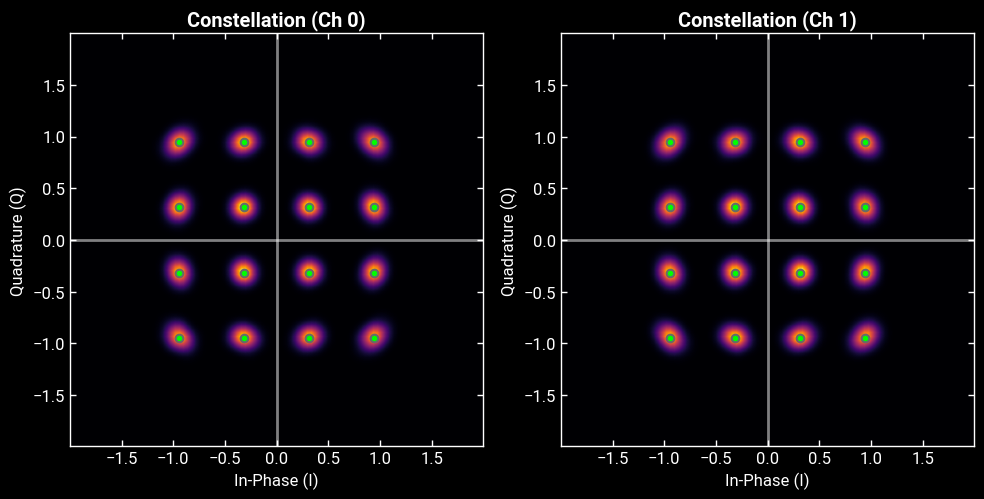

In [ ]:
eq = preeqsig.copy()
eq.samples = res.y_hat
eq.sampling_rate = preeqsig.symbol_rate

eq.resolve_symbols()
eq.resolve_phase_ambiguity()
eq.demap_symbols_hard()


eq.evm(mode="blind")
eq.ser(num_train_symbols=num_train_symbols)
eq.snr(num_train_symbols=num_train_symbols)

eq.ser(num_train_symbols=num_train_symbols * 2)
eq.snr(num_train_symbols=num_train_symbols * 2)

eq.plot_constellation(show=True, overlay_ideal=True)


2026-05-16 10:27:58 [INFO] [commstools/sync.py] CPR (BPS, B=1024, joint): phase mean=89.99°, std=1.28° [6144 blocks x 8 symbols, C=2, cycle_slip_correction=False]


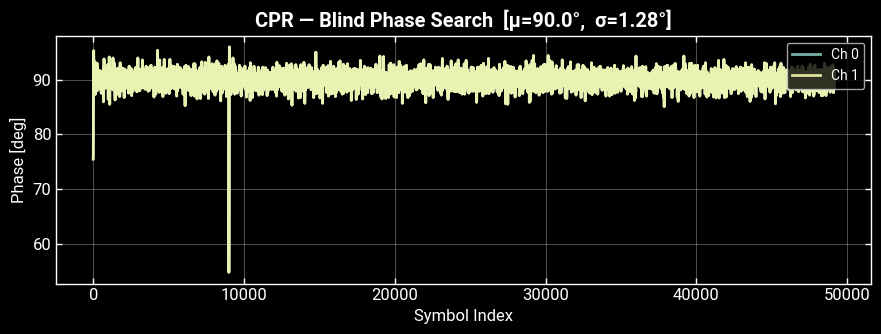

2026-05-16 10:27:58 [WARNING] [commstools/sync.py] loop_filter='butterworth': mu and beta are ignored. Use loop_bandwidth_normalized to control loop bandwidth.
2026-05-16 10:27:58 [INFO] [commstools/sync.py] CPR (DD-PLL, Butterworth, BW=0.05): phase mean=879.02°, std=544.71° [C=2]


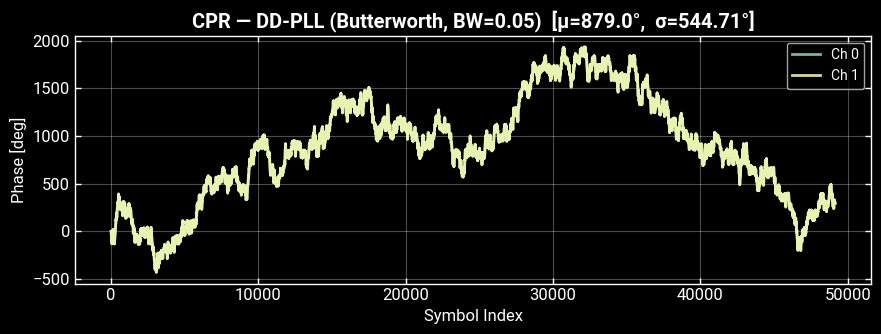

2026-05-16 10:27:58 [INFO] [commstools/core.py] Signal already at 1 sps, no downsampling needed.
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER: 8.17e-01 (40163/49152 errors)
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER: 1.83e-01 (8994/49152 errors)
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-05-16 10:27:58 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=0, best_k=2, rotation=180.0°, SER=0.1830
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER: 8.17e-01 (40164/49152 errors)
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER: 1.83e-01 (8995/49152 errors)
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER: 1.00e+00 (49152/49152 errors)
2026-05-16 10:27:58 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=1, best_k=2, rotat

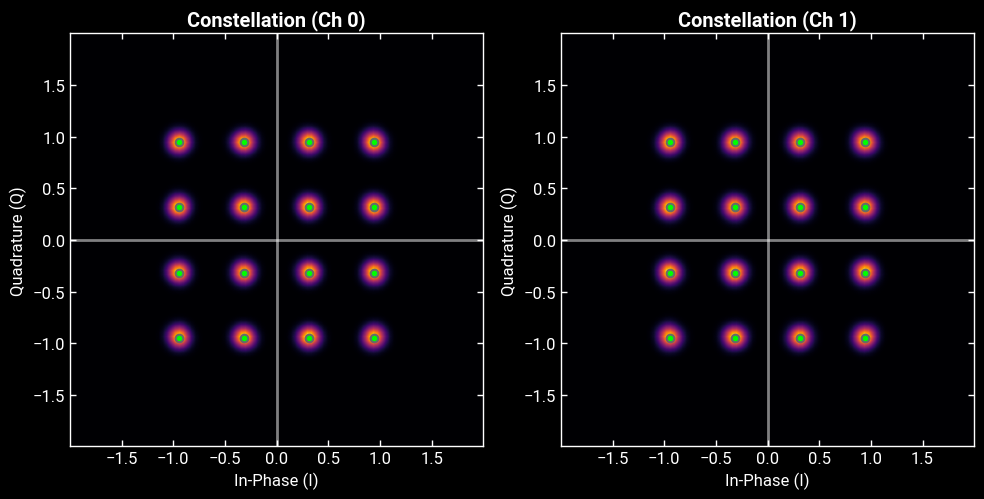

2026-05-16 10:27:58 [INFO] [commstools/metrics.py] EVM [blind] Ch0: 7.81% (-22.15 dB)
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] EVM [blind] Ch1: 7.95% (-21.99 dB)
2026-05-16 10:27:58 [INFO] [commstools/core.py] Discarding 8192 training symbols for SER calculation.
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER Ch0: 1.96e-02 (802/40960 errors)
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER Ch1: 1.96e-02 (803/40960 errors)
2026-05-16 10:27:58 [INFO] [commstools/core.py] Discarding 8192 training symbols for SNR calculation.
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SNR Ch0: 13.67 dB
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SNR Ch1: 13.48 dB
2026-05-16 10:27:58 [INFO] [commstools/core.py] Discarding 16384 training symbols for SER calculation.
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER Ch0: 6.10e-05 (2/32768 errors)
2026-05-16 10:27:58 [INFO] [commstools/metrics.py] SER Ch1: 6.10e-05 (2/32768 errors)
2026-05-16 10:27:58 [INFO] [commsto

array([22.181786, 22.016832], dtype=float32)

In [36]:
# CPR
phases_bps = recover_carrier_phase_bps(
    eq.samples,
    modulation=eq.mod_scheme,
    order=eq.mod_order,
    debug_plot=True,
    block_size=8,
    num_test_phases=1024,
    cycle_slip_correction=cpr_cycle_slip_correction,
    cycle_slip_history=cpr_cycle_slip_history // 2,
    cycle_slip_threshold=xp.pi / 4,
    joint_channels=True,
)
phases_pll = recover_carrier_phase_pll(
    eq.samples,
    modulation=eq.mod_scheme,
    order=eq.mod_order,
    debug_plot=True,
    loop_filter="butterworth",
    loop_bandwidth_normalized=cpr_pll_bandwidth,
    mu=0.2,
    beta=0.00025,
    cycle_slip_correction=cpr_cycle_slip_correction,
    cycle_slip_history=cpr_cycle_slip_history,
    joint_channels=True,
)

# Recover carrier phase

eqfoecpr = eq.copy()

eqfoecpr.samples = correct_carrier_phase(eqfoecpr.samples, phases_bps)

eqfoecpr.resolve_symbols()
eqfoecpr.resolve_phase_ambiguity()
eqfoecpr.demap_symbols_hard()

eqfoecpr.plot_constellation(show=True, overlay_ideal=True)


eqfoecpr.evm(mode="blind")
eqfoecpr.ser(num_train_symbols=num_train_symbols)
eqfoecpr.snr(num_train_symbols=num_train_symbols)

eqfoecpr.ser(num_train_symbols=num_train_symbols * 2)
eqfoecpr.snr(num_train_symbols=num_train_symbols * 2)
